# Slingshot 🎯
### "Buy the laggard, sell the leader." On futures it was worth nothing. On stocks it's a *real* edge — that you still can't trade.

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Decayed since 2020?: Confirmed](https://img.shields.io/badge/Decayed_since_2020%3F-Confirmed-8b949e?style=flat-square)

This is the twin of [Rip-Tide](../../32-rip-tide/). There we faded each futures market against its own past and found **no premium at all** (gross Sharpe 0.08). Here we fade each *stock* against the **cross-section of its peers** — short the names that ran ahead of the pack, buy the ones that lagged, dollar-neutral. And this time the edge is *real*: short-term reversal is one of the oldest, sturdiest anomalies in equities. The catch is the same one that haunts the whole desk — the book has to churn almost completely every day, and the premium hides in exactly the names that cost the most to trade.

> 📓 **Plain-language layer.** The cost wall, the break-even, the horizon knife-edge and the holding-period rescue are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> ⚠️ **Not investment advice.** Charts below are generated by the code beside them; the core runs on a **synthetic** panel, so the real S&P 500 numbers (from [`../docs/results.md`](../docs/results.md)) are a measurement. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
sys.path.insert(0, os.path.abspath("../../.."))
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.2)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
from slingshot import data, strategy, costs, extension

# Offline synthetic control: a panel with idiosyncratic OU overshoot (the machinery) + a random-walk null.
# The real S&P 500 verdict is in ../docs/results.md.
r, _, truth = data.synthetic_panel(revert_strength=0.06, seed=33)
r0, _, _ = data.synthetic_panel(revert_strength=0.0, seed=33)
print(f"synthetic control: {truth.n_stocks} stocks x {truth.n_bars} days, revert_strength {truth.revert_strength} (null=0)")


synthetic control: 150 stocks x 4032 days, revert_strength 0.06 (null=0)


## The answer first 🎯

| What we asked | The honest answer |
|---|---|
| Is cross-sectional reversal real in stocks? | 🟩 **Yes.** Dollar-neutral gross Sharpe **0.70**, +skew **+0.73** — a genuine premium (futures managed just 0.08). |
| Could you trade it? | 🟥 **No.** Turnover **0.63**/day ⇒ **break-even 3.31 bp**, and the edge lives in the least-liquid names. Net @5 bp: **-0.36**. |
| Is it still there? | ⚪ **Fading.** Net sub-period Sharpe -0.14/-0.04/**-0.85** — worst in the HFT era. |

> Desk shorthand: **Signal `REAL` · Tradability `MIRAGE` · Decayed? `CONFIRMED`** — real to measure, a mirage to trade.

## 1 · The claim 📣

Single-group mean-reversion (Kakushadze-Serur §3.9; lineage Jegadeesh 1990, Lehmann 1990):

1. **Signal** — each stock's trailing 5-day return *relative to the cross-section*, negated. Short the relative leaders, long the relative laggards.
2. **Dollar-neutral** — long and short legs net to zero, gross exposure normalised to 1.
3. **Daily rebalance** — refresh every day; the book turns over almost completely.

The believer's case: crowds overreact to idiosyncratic news, and someone gets paid to lean against it. That someone is a liquidity provider — which is exactly why the premium should live in single stocks, not in deep index futures.

synthetic gross Sharpe 10.0  (null ~0)


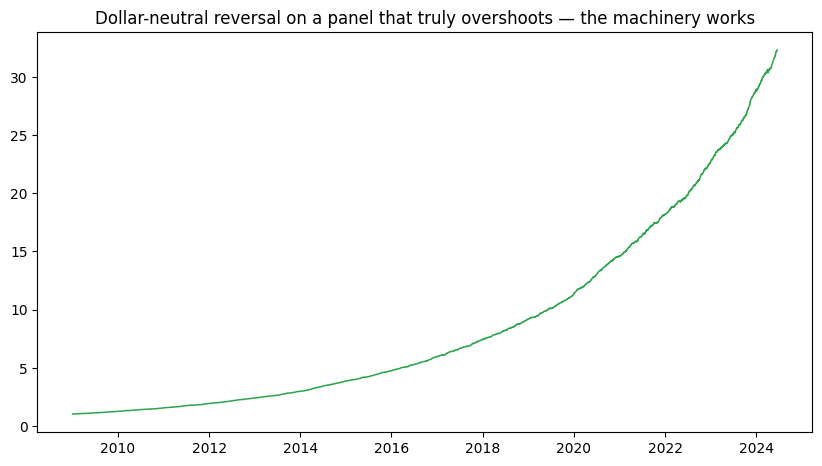

In [2]:
book = strategy.book_returns(r, cost_bps=0.0)   # GROSS, on the synthetic control
eq = (1+book).cumprod()
fig, ax = plt.subplots()
ax.plot(eq.index, eq.values, color='#2ea44f', lw=1.1)
ax.set_title('Dollar-neutral reversal on a panel that truly overshoots — the machinery works')
s = strategy.summary(book); print(f"synthetic gross Sharpe {s['sharpe']:.1f}  (null ~0)")

## 2 · So what? 💰

A real, market-neutral, positive-skew return stream that works in any market direction is the core of every equity stat-arb desk. And reversal genuinely *is* real — so the question isn't whether the effect exists, but whether *you* can keep any of it after paying to trade a book that rebuilds itself daily. That gap — between a real signal and a tradable one — is the whole lesson of this desk, and reversal is its cleanest example.

## 3 · How we'd know 🔬

1. **Real?** Gross-of-cost Sharpe on the real panel (and flat on a null).
2. **Tradable?** Turnover, break-even cost, and net Sharpe at realistic equity costs.
3. **Still there?** Sub-period Sharpe — has the premium decayed as faster players entered?

**Mirage line:** break-even cost inside the realistic S&P round-trip band (~2–10 bp) — then only the most-liquid, least-profitable slice could ever be traded.

## 4 · The teardown 🔧

### 4a · The machinery works where reversal is real (control vs null)

In [3]:
for label, rr in [('reverting panel', r), ('null (random walk)', r0)]:
    s = strategy.summary(strategy.book_returns(rr, cost_bps=0.0))
    print(f"{label:22} gross Sharpe {s['sharpe']:+6.2f}  turnover/day {strategy.turnover(rr):.2f}")

reverting panel        gross Sharpe +10.00  turnover/day 0.68


null (random walk)     gross Sharpe  -0.14  turnover/day 0.63


### 4b · On the real S&P 500 — real gross, gone net
467 names, 2010–2026 ([`../docs/results.md`](../docs/results.md)):

- **Gross** Sharpe **0.70** (CAGR 5.1%, skew +0.73) — a *real* premium, where the futures version (Rip-Tide) managed only **0.08**.
- But turnover is **0.63/day**, so the **break-even cost is 3.31 bp** — inside the realistic cost band, and the edge concentrates in the *least* liquid names.
- Net of a gentle 5 bp the Sharpe is **-0.36**; at 10 bp, **-1.42**.

Real tape (../docs/results.md):
  reversal gross   Sharpe 0.70  CAGR 5.1%  maxDD -20%  skew +0.73
  reversal net@5bp Sharpe -0.36
  reversal net@10bp Sharpe -1.42
  turnover/day 0.63   break-even 3.31 bp   (futures gross was 0.08)


Text(0.5, 1.0, 'The cost wall — daily turnover meets the spread')

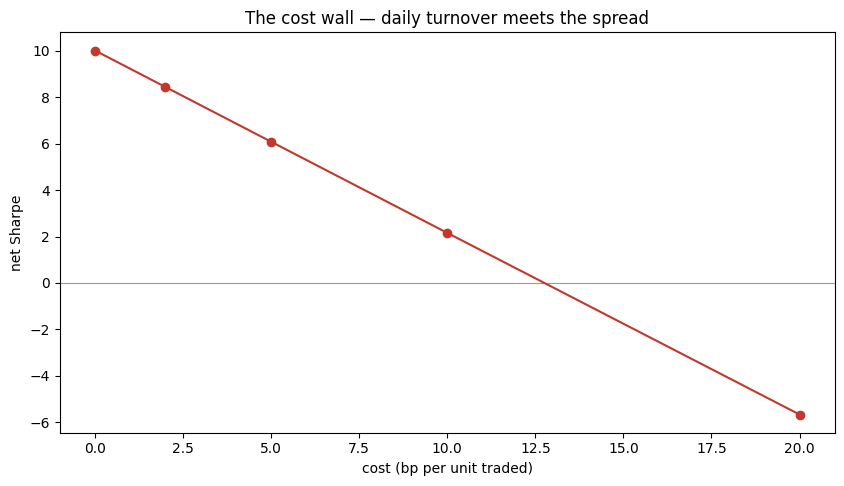

In [4]:
print('Real tape (../docs/results.md):')
print('  reversal gross   Sharpe 0.70  CAGR 5.1%  maxDD -20%  skew +0.73')
print('  reversal net@5bp Sharpe -0.36')
print('  reversal net@10bp Sharpe -1.42')
print('  turnover/day 0.63   break-even 3.31 bp   (futures gross was 0.08)')
# the cost wall, drawn on the synthetic where there IS an edge to erode:
cs = costs.cost_sweep(r)
fig, ax = plt.subplots(); ax.axhline(0, color='#999', lw=.8)
ax.plot(cs.index, cs['sharpe'], marker='o', color='#c0392b')
ax.set_xlabel('cost (bp per unit traded)'); ax.set_ylabel('net Sharpe'); ax.set_title('The cost wall — daily turnover meets the spread')

## 5 · The verdict 🧾

- **Signal `REAL`** — gross Sharpe 0.70, +skew, market-neutral; not the 0.08 of futures.
- **Tradability `MIRAGE`** — break-even 3.31 bp, net @5 bp -0.36; premium lives in the costliest names.
- **Decayed `CONFIRMED`** — net sub-period -0.14/-0.04/-0.85, worst lately.

> **The equity mirror of Rip-Tide.** Reversal is a single-stock, liquidity-provision premium — real, but micro-flavoured and cost-dominated, and absent on deep futures.

## 6 · Could you trade it? 💸

- **Not as shown.** Break-even 3.31 bp is inside what it costs to trade an average S&P name round-trip; for the smaller names — where the signal is strongest — you'd pay more.
- **The cruel irony.** Avramov–Chordia–Goyal (2006): reversal is *strongest in illiquid stocks* and *weakest in liquid ones* — so the only slice you can trade cheaply is the slice with almost no edge.
- **And it's fading.** Khandani–Lo (2007): stat-arb capital and HFT have competed the premium down; our 2020–2026 net Sharpe is the worst of the three sub-periods.

## 7 · Going further 🚪

### Worked complement — "slow it down to escape costs" ([`../docs/extension.md`](../docs/extension.md))
The book dies on turnover, so we hold each day's weights longer:

- Turnover falls ~9× from daily to a 21-day hold — the cost side works.
- Unlike Rip-Tide (flatly busted), the net Sharpe *just* crosses zero: **+0.10** at a 21-day hold. But +0.10 is within noise and below any hurdle — it confirms a real premium hiding under the turnover, not an investable strategy.

### Other forks
- **Liquidity-tiered** — trade only the least-liquid quintile (biggest edge) with *honest* higher spreads.
- **Sector-neutral** — demean within GICS sector to strip industry bets.
- **Crisis-conditional** — size up only when dispersion/VIX is high (Nagel 2012).

PRs welcome — try the liquidity-tiered book, sector-neutralise, or gate on dispersion.